# 22_E14 - Agente/orquestador IA

Este notebook implementa el primer prototipo de **agente/orquestador IA** del proyecto.

No entrena modelos nuevos. Usa las salidas de E13 para construir una capa de decisión:

- consolida una worklist multiplanar,
- identifica plano y modelo asociado,
- interpreta quality flags,
- calcula prioridad de revisión,
- genera reportes por caso,
- deja un reporte global para la tesis/MVP.

**Importante:** el agente no reemplaza al profesional. Solo organiza la salida de IA y marca casos que requieren revisión con mayor atención.


In [1]:
import ast
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 200)

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

PFI_ROOT = Path("/content/drive/MyDrive/PFI_MVP")

E13_ROOT = PFI_ROOT / "results" / "E13_multiplanar_inference_pipeline"
E14_ROOT = PFI_ROOT / "results" / "E14_ai_agent_orchestrator"
FIGURES_ROOT = PFI_ROOT / "figures"
DOCS_ROOT = PFI_ROOT / "docs"
CASE_REPORTS_ROOT = DOCS_ROOT / "E14_agent_case_reports"

for p in [E14_ROOT, FIGURES_ROOT, DOCS_ROOT, CASE_REPORTS_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

AXIAL_QUALITY_PATH = E13_ROOT / "E13_axial_examples_quality.csv"
AXIAL_METRICS_PATH = E13_ROOT / "E13_axial_examples_metrics_by_class.csv"
SAG_QUALITY_PATH = E13_ROOT / "E13_sagittal_examples_quality.csv"
SAG_METRICS_PATH = E13_ROOT / "E13_sagittal_examples_metrics_by_class.csv"
E13_REPORT_PATH = E13_ROOT / "E13_multiplanar_pipeline_report.json"

required = [
    AXIAL_QUALITY_PATH,
    AXIAL_METRICS_PATH,
    SAG_QUALITY_PATH,
    SAG_METRICS_PATH,
    E13_REPORT_PATH,
]

for p in required:
    print(p, "->", p.exists())
    assert p.exists(), f"Falta archivo requerido: {p}"

print("E14_ROOT:", E14_ROOT)


Mounted at /content/drive
/content/drive/MyDrive/PFI_MVP/results/E13_multiplanar_inference_pipeline/E13_axial_examples_quality.csv -> True
/content/drive/MyDrive/PFI_MVP/results/E13_multiplanar_inference_pipeline/E13_axial_examples_metrics_by_class.csv -> True
/content/drive/MyDrive/PFI_MVP/results/E13_multiplanar_inference_pipeline/E13_sagittal_examples_quality.csv -> True
/content/drive/MyDrive/PFI_MVP/results/E13_multiplanar_inference_pipeline/E13_sagittal_examples_metrics_by_class.csv -> True
/content/drive/MyDrive/PFI_MVP/results/E13_multiplanar_inference_pipeline/E13_multiplanar_pipeline_report.json -> True
E14_ROOT: /content/drive/MyDrive/PFI_MVP/results/E14_ai_agent_orchestrator


## 1. Cargar salidas de E13

E14 trabaja encima de E13. Por eso usa los CSV de calidad, métricas por clase y el reporte del pipeline común.


In [2]:
axial_quality_df = pd.read_csv(AXIAL_QUALITY_PATH)
axial_metrics_df = pd.read_csv(AXIAL_METRICS_PATH)
sag_quality_df = pd.read_csv(SAG_QUALITY_PATH)
sag_metrics_df = pd.read_csv(SAG_METRICS_PATH)
e13_report = json.loads(E13_REPORT_PATH.read_text(encoding="utf-8"))

print("Axial quality:", axial_quality_df.shape)
print("Axial metrics:", axial_metrics_df.shape)
print("Sagittal quality:", sag_quality_df.shape)
print("Sagittal metrics:", sag_metrics_df.shape)

display(axial_quality_df.head())
display(sag_quality_df.head())


Axial quality: (6, 11)
Axial metrics: (36, 10)
Sagittal quality: (6, 18)
Sagittal metrics: (24, 11)


,example_id,plane,case_id_norm,disc_id,figure_path,foreground_ratio,n_components,present_classes,flags,mean_confidence,mean_fg_confidence
0,1,axial,7,3,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_01.png,0.067642,5,"[1, 2, 3, 4, 5]",[],0.989182,0.954711
1,2,axial,7,4,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_02.png,0.072937,12,"[1, 2, 3, 4, 5]",['muchos_componentes'],0.989175,0.955937
2,3,axial,7,5,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_03.png,0.069839,2,"[1, 2, 3, 4, 5]",[],0.989071,0.968347
3,4,axial,15,3,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_04.png,0.058350,9,"[1, 2, 3, 4, 5]",[],0.989828,0.942657
4,5,axial,15,4,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_05.png,0.062454,2,"[1, 2, 3, 4, 5]",[],0.989410,0.944314


,example_id,plane,case_id,selected_axis,slice_index,selection_score,original_shape_zyx,original_slice_shape,axis_candidates,image_path,mask_path,figure_path,foreground_ratio,n_components,present_classes,flags,mean_confidence,mean_fg_confidence
0,1,sagittal,101_t1,2,8,0.226307,"(298, 320, 17)","(298, 320)","[{""axis"": 0, ""n_slices"": 298, ""slice_2d_shape"": [320, 17], ""valid_2d"": false}, {""axis"": 1, ""n_slices"": 320, ""slice_2d_shape"": [298, 17], ""valid_2d"": false}, {""axis"": 2, ""n_slices"": 17, ""slice_2d_s...",/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/101_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/101_t1.mha,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_dynamic_example_01.png,0.181458,13,"[1, 2, 3]",['muchos_componentes'],0.907111,0.843732
1,2,sagittal,116_t1,2,5,0.162707,"(320, 320, 15)","(320, 320)","[{""axis"": 0, ""n_slices"": 320, ""slice_2d_shape"": [320, 15], ""valid_2d"": false}, {""axis"": 1, ""n_slices"": 320, ""slice_2d_shape"": [320, 15], ""valid_2d"": false}, {""axis"": 2, ""n_slices"": 15, ""slice_2d_s...",/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/116_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/116_t1.mha,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_dynamic_example_02.png,0.106369,12,"[1, 2, 3]",['muchos_componentes'],0.917606,0.853816
2,3,sagittal,117_t1,2,13,0.163138,"(448, 448, 24)","(448, 448)","[{""axis"": 0, ""n_slices"": 448, ""slice_2d_shape"": [448, 24], ""valid_2d"": false}, {""axis"": 1, ""n_slices"": 448, ""slice_2d_shape"": [448, 24], ""valid_2d"": false}, {""axis"": 2, ""n_slices"": 24, ""slice_2d_s...",/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/117_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/117_t1.mha,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_dynamic_example_03.png,0.115646,14,"[1, 2, 3]",['muchos_componentes'],0.924658,0.857124
3,4,sagittal,12_t1,2,8,0.201606,"(320, 320, 15)","(320, 320)","[{""axis"": 0, ""n_slices"": 320, ""slice_2d_shape"": [320, 15], ""valid_2d"": false}, {""axis"": 1, ""n_slices"": 320, ""slice_2d_shape"": [320, 15], ""valid_2d"": false}, {""axis"": 2, ""n_slices"": 15, ""slice_2d_s...",/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/12_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/12_t1.mha,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_dynamic_example_04.png,0.152420,11,"[1, 2, 3]",['muchos_componentes'],0.922323,0.888282
4,5,sagittal,131_t1,2,12,0.190269,"(463, 448, 24)","(463, 448)","[{""axis"": 0, ""n_slices"": 463, ""slice_2d_shape"": [448, 24], ""valid_2d"": false}, {""axis"": 1, ""n_slices"": 448, ""slice_2d_shape"": [463, 24], ""valid_2d"": false}, {""axis"": 2, ""n_slices"": 24, ""slice_2d_s...",/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/131_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/131_t1.mha,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_dynamic_example_05.png,0.146667,7,"[1, 2, 3]",[],0.922671,0.861709


## 2. Normalización de worklist multiplanar

Se arma una lista común de estudios/ejemplos para el agente. Cada fila queda con un esquema homogéneo, sin importar si viene del modelo axial o sagital.


In [3]:
def parse_maybe_list(value):
    if isinstance(value, list):
        return value
    if pd.isna(value):
        return []
    if isinstance(value, str):
        value = value.strip()
        if value == "":
            return []
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return parsed
            return [parsed]
        except Exception:
            return [value]
    return [value]


def normalize_flags(row):
    flags = parse_maybe_list(row.get("flags", []))
    return [str(f) for f in flags]


def normalize_present_classes(row):
    values = parse_maybe_list(row.get("present_classes", []))
    out = []
    for v in values:
        try:
            out.append(int(v))
        except Exception:
            out.append(v)
    return out


worklist_rows = []

for _, r in axial_quality_df.iterrows():
    case_id = str(r.get("case_id_norm", ""))
    disc_id = int(r.get("disc_id", -1))
    worklist_rows.append({
        "agent_item_id": f"AXIAL_{int(r['example_id']):03d}",
        "plane": "axial",
        "model_key": "axial_t2_alkafri",
        "case_ref": f"case={case_id} | D={disc_id}",
        "case_id": case_id,
        "disc_id": disc_id,
        "selected_axis": None,
        "slice_index": None,
        "figure_path": r.get("figure_path"),
        "foreground_ratio": float(r.get("foreground_ratio", np.nan)),
        "n_components": int(r.get("n_components", -1)),
        "present_classes": normalize_present_classes(r),
        "flags": normalize_flags(r),
        "mean_confidence": float(r.get("mean_confidence", np.nan)),
        "mean_fg_confidence": float(r.get("mean_fg_confidence", np.nan)),
    })

for _, r in sag_quality_df.iterrows():
    case_id = str(r.get("case_id", ""))
    worklist_rows.append({
        "agent_item_id": f"SAG_{int(r['example_id']):03d}",
        "plane": "sagittal",
        "model_key": "sagittal_spider",
        "case_ref": f"case={case_id}",
        "case_id": case_id,
        "disc_id": None,
        "selected_axis": int(r.get("selected_axis", -1)),
        "slice_index": int(r.get("slice_index", -1)),
        "figure_path": r.get("figure_path"),
        "foreground_ratio": float(r.get("foreground_ratio", np.nan)),
        "n_components": int(r.get("n_components", -1)),
        "present_classes": normalize_present_classes(r),
        "flags": normalize_flags(r),
        "mean_confidence": float(r.get("mean_confidence", np.nan)),
        "mean_fg_confidence": float(r.get("mean_fg_confidence", np.nan)),
    })

worklist_df = pd.DataFrame(worklist_rows)
worklist_path = E14_ROOT / "E14_agent_worklist.csv"
worklist_df.to_csv(worklist_path, index=False)

display(worklist_df)
print("Worklist:", worklist_path)


,agent_item_id,plane,model_key,case_ref,case_id,disc_id,selected_axis,slice_index,figure_path,foreground_ratio,n_components,present_classes,flags,mean_confidence,mean_fg_confidence
0,AXIAL_001,axial,axial_t2_alkafri,case=7 | D=3,7,3.0,NaN,NaN,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_01.png,0.067642,5,"[1, 2, 3, 4, 5]",[],0.989182,0.954711
1,AXIAL_002,axial,axial_t2_alkafri,case=7 | D=4,7,4.0,NaN,NaN,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_02.png,0.072937,12,"[1, 2, 3, 4, 5]",[muchos_componentes],0.989175,0.955937
2,AXIAL_003,axial,axial_t2_alkafri,case=7 | D=5,7,5.0,NaN,NaN,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_03.png,0.069839,2,"[1, 2, 3, 4, 5]",[],0.989071,0.968347
3,AXIAL_004,axial,axial_t2_alkafri,case=15 | D=3,15,3.0,NaN,NaN,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_04.png,0.058350,9,"[1, 2, 3, 4, 5]",[],0.989828,0.942657
4,AXIAL_005,axial,axial_t2_alkafri,case=15 | D=4,15,4.0,NaN,NaN,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_05.png,0.062454,2,"[1, 2, 3, 4, 5]",[],0.989410,0.944314
5,AXIAL_006,axial,axial_t2_alkafri,case=15 | D=5,15,5.0,NaN,NaN,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_06.png,0.063629,8,"[1, 2, 3, 4, 5]",[],0.989412,0.949532
6,SAG_001,sagittal,sagittal_spider,case=101_t1,101_t1,NaN,2.0,8.0,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_dynamic_example_01.png,0.181458,13,"[1, 2, 3]",[muchos_componentes],0.907111,0.843732
7,SAG_002,sagittal,sagittal_spider,case=116_t1,116_t1,NaN,2.0,5.0,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_dynamic_example_02.png,0.106369,12,"[1, 2, 3]",[muchos_componentes],0.917606,0.853816
8,SAG_003,sagittal,sagittal_spider,case=117_t1,117_t1,NaN,2.0,13.0,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_dynamic_example_03.png,0.115646,14,"[1, 2, 3]",[muchos_componentes],0.924658,0.857124
9,SAG_004,sagittal,sagittal_spider,case=12_t1,12_t1,NaN,2.0,8.0,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_dynamic_example_04.png,0.152420,11,"[1, 2, 3]",[muchos_componentes],0.922323,0.888282


Worklist: /content/drive/MyDrive/PFI_MVP/results/E14_ai_agent_orchestrator/E14_agent_worklist.csv


## 3. Reglas del agente

El agente aplica reglas simples, trazables y defendibles para un prototipo:

- siempre requiere revisión profesional,
- diferencia revisión estándar de revisión prioritaria,
- marca casos con baja confianza, foreground anómalo o demasiados componentes,
- conserva el modelo seleccionado y las razones de decisión.


In [4]:
def agent_priority_and_action(row):
    flags = list(row.get("flags", []))
    plane = row.get("plane")
    fg = float(row.get("foreground_ratio", np.nan))
    n_components = int(row.get("n_components", -1))
    mean_conf = float(row.get("mean_confidence", np.nan))
    mean_fg_conf = float(row.get("mean_fg_confidence", np.nan))
    present_classes = list(row.get("present_classes", []))

    reasons = []

    # Reglas críticas comunes
    if not present_classes:
        reasons.append("no se detectaron clases no-fondo")

    if np.isfinite(mean_conf) and mean_conf < 0.75:
        reasons.append("confianza media baja")

    if np.isfinite(mean_fg_conf) and mean_fg_conf < 0.75:
        reasons.append("confianza baja en foreground")

    # Reglas por plano
    if plane == "axial":
        expected_model = "axial_t2_alkafri"

        if np.isfinite(fg) and fg < 0.005:
            reasons.append("foreground axial demasiado bajo")

        if np.isfinite(fg) and fg > 0.25:
            reasons.append("foreground axial demasiado alto")

        if n_components > 10:
            reasons.append("muchos componentes en máscara axial")

    elif plane == "sagittal":
        expected_model = "sagittal_spider"

        if np.isfinite(fg) and fg < 0.01:
            reasons.append("foreground sagital demasiado bajo")

        if np.isfinite(fg) and fg > 0.45:
            reasons.append("foreground sagital demasiado alto")

        # En sagital, muchos componentes es frecuente por discos/vértebras; se marca como atención, no necesariamente error.
        if n_components > 20:
            reasons.append("muchos componentes sagitales; revisar continuidad anatómica")
        elif n_components > 10:
            reasons.append("componentes múltiples esperables, revisar visualmente")

    else:
        expected_model = "unknown"
        reasons.append("plano no reconocido")

    # Incorporar flags originales de E13
    for f in flags:
        if f not in reasons:
            reasons.append(f"flag E13: {f}")

    severe_terms = [
        "no se detectaron",
        "confianza baja",
        "foreground axial demasiado bajo",
        "foreground axial demasiado alto",
        "foreground sagital demasiado bajo",
        "foreground sagital demasiado alto",
    ]

    if any(any(term in r for term in severe_terms) for r in reasons):
        priority = "alta"
        status = "requiere_revision_prioritaria"
        recommended_action = "Revisar overlay y considerar repetir preprocesamiento/inferencia antes de usar el resultado."
    elif len(reasons) > 0:
        priority = "media"
        status = "requiere_revision_con_atencion"
        recommended_action = "Revisar visualmente el overlay; si la anatomía es coherente, puede pasar a validación profesional."
    else:
        priority = "baja"
        status = "listo_para_revision_estandar"
        recommended_action = "Enviar a revisión profesional estándar como resultado asistido por IA."

    return pd.Series({
        "expected_model": expected_model,
        "agent_status": status,
        "review_priority": priority,
        "agent_reasons": reasons,
        "recommended_action": recommended_action,
        "human_review_required": True,
    })


agent_decisions_df = worklist_df.copy()
agent_decisions_df = pd.concat(
    [agent_decisions_df, agent_decisions_df.apply(agent_priority_and_action, axis=1)],
    axis=1,
)

decisions_path = E14_ROOT / "E14_agent_decisions.csv"
agent_decisions_df.to_csv(decisions_path, index=False)

display(agent_decisions_df)
print("Decisions:", decisions_path)


,agent_item_id,plane,model_key,case_ref,case_id,disc_id,selected_axis,slice_index,figure_path,foreground_ratio,n_components,present_classes,flags,mean_confidence,mean_fg_confidence,expected_model,agent_status,review_priority,agent_reasons,recommended_action,human_review_required
0,AXIAL_001,axial,axial_t2_alkafri,case=7 | D=3,7,3.0,NaN,NaN,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_01.png,0.067642,5,"[1, 2, 3, 4, 5]",[],0.989182,0.954711,axial_t2_alkafri,listo_para_revision_estandar,baja,[],Enviar a revisión profesional estándar como resultado asistido por IA.,True
1,AXIAL_002,axial,axial_t2_alkafri,case=7 | D=4,7,4.0,NaN,NaN,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_02.png,0.072937,12,"[1, 2, 3, 4, 5]",[muchos_componentes],0.989175,0.955937,axial_t2_alkafri,requiere_revision_con_atencion,media,"[muchos componentes en máscara axial, flag E13: muchos_componentes]","Revisar visualmente el overlay; si la anatomía es coherente, puede pasar a validación profesional.",True
2,AXIAL_003,axial,axial_t2_alkafri,case=7 | D=5,7,5.0,NaN,NaN,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_03.png,0.069839,2,"[1, 2, 3, 4, 5]",[],0.989071,0.968347,axial_t2_alkafri,listo_para_revision_estandar,baja,[],Enviar a revisión profesional estándar como resultado asistido por IA.,True
3,AXIAL_004,axial,axial_t2_alkafri,case=15 | D=3,15,3.0,NaN,NaN,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_04.png,0.058350,9,"[1, 2, 3, 4, 5]",[],0.989828,0.942657,axial_t2_alkafri,listo_para_revision_estandar,baja,[],Enviar a revisión profesional estándar como resultado asistido por IA.,True
4,AXIAL_005,axial,axial_t2_alkafri,case=15 | D=4,15,4.0,NaN,NaN,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_05.png,0.062454,2,"[1, 2, 3, 4, 5]",[],0.989410,0.944314,axial_t2_alkafri,listo_para_revision_estandar,baja,[],Enviar a revisión profesional estándar como resultado asistido por IA.,True
5,AXIAL_006,axial,axial_t2_alkafri,case=15 | D=5,15,5.0,NaN,NaN,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_06.png,0.063629,8,"[1, 2, 3, 4, 5]",[],0.989412,0.949532,axial_t2_alkafri,listo_para_revision_estandar,baja,[],Enviar a revisión profesional estándar como resultado asistido por IA.,True
6,SAG_001,sagittal,sagittal_spider,case=101_t1,101_t1,NaN,2.0,8.0,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_dynamic_example_01.png,0.181458,13,"[1, 2, 3]",[muchos_componentes],0.907111,0.843732,sagittal_spider,requiere_revision_con_atencion,media,"[componentes múltiples esperables, revisar visualmente, flag E13: muchos_componentes]","Revisar visualmente el overlay; si la anatomía es coherente, puede pasar a validación profesional.",True
7,SAG_002,sagittal,sagittal_spider,case=116_t1,116_t1,NaN,2.0,5.0,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_dynamic_example_02.png,0.106369,12,"[1, 2, 3]",[muchos_componentes],0.917606,0.853816,sagittal_spider,requiere_revision_con_atencion,media,"[componentes múltiples esperables, revisar visualmente, flag E13: muchos_componentes]","Revisar visualmente el overlay; si la anatomía es coherente, puede pasar a validación profesional.",True
8,SAG_003,sagittal,sagittal_spider,case=117_t1,117_t1,NaN,2.0,13.0,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_dynamic_example_03.png,0.115646,14,"[1, 2, 3]",[muchos_componentes],0.924658,0.857124,sagittal_spider,requiere_revision_con_atencion,media,"[componentes múltiples esperables, revisar visualmente, flag E13: muchos_componentes]","Revisar visualmente el overlay; si la anatomía es coherente, puede pasar a validación profesional.",True
9,SAG_004,sagittal,sagittal_spider,case=12_t1,12_t1,NaN,2.0,8.0,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_dynamic_example_04.png,0.152420,11,"[1, 2, 3]",[muchos_componentes],0.922323,0.888282,sagittal_spider,requiere_revision_con_atencion,media,"[componentes múltiples esperables, revisar visualmente, flag E13: muchos_componentes]","Revisar visualmente el overlay; si la anato

Decisions: /content/drive/MyDrive/PFI_MVP/results/E14_ai_agent_orchestrator/E14_agent_decisions.csv


## 4. Métricas resumen por caso

Además de quality flags, el agente resume métricas por clases principales cuando hay ground truth.


In [5]:
def summarize_metrics_by_example(metrics_df, plane):
    rows = []

    if len(metrics_df) == 0:
        return pd.DataFrame()

    for example_id, g in metrics_df.groupby("example_id"):
        if plane == "axial":
            # Lectura completa sin fondo y lectura útil excluyendo raw_0, coherente con E11.
            no_bg = g[g["class_id"] != 0]
            useful = g[g["class_id"].isin([2, 3, 4, 5])]
            case_id = str(g["case_id_norm"].iloc[0]) if "case_id_norm" in g.columns else ""
            disc_id = int(g["disc_id"].iloc[0]) if "disc_id" in g.columns else None
            item_id = f"AXIAL_{int(example_id):03d}"
            case_ref = f"case={case_id} | D={disc_id}"
        else:
            no_bg = g[g["class_id"] != 0]
            useful = no_bg
            case_id = str(g["case_id"].iloc[0]) if "case_id" in g.columns else ""
            item_id = f"SAG_{int(example_id):03d}"
            case_ref = f"case={case_id}"

        rows.append({
            "agent_item_id": item_id,
            "plane": plane,
            "case_ref": case_ref,
            "dice_macro_no_bg": float(no_bg["dice"].mean()) if len(no_bg) else np.nan,
            "iou_macro_no_bg": float(no_bg["iou"].mean()) if len(no_bg) else np.nan,
            "dice_macro_useful_classes": float(useful["dice"].mean()) if len(useful) else np.nan,
            "iou_macro_useful_classes": float(useful["iou"].mean()) if len(useful) else np.nan,
            "min_class_dice_no_bg": float(no_bg["dice"].min()) if len(no_bg) else np.nan,
        })

    return pd.DataFrame(rows)


axial_metrics_summary = summarize_metrics_by_example(axial_metrics_df, "axial")
sag_metrics_summary = summarize_metrics_by_example(sag_metrics_df, "sagittal")

metrics_summary_df = pd.concat([axial_metrics_summary, sag_metrics_summary], ignore_index=True)

agent_full_df = agent_decisions_df.merge(
    metrics_summary_df,
    on=["agent_item_id", "plane", "case_ref"],
    how="left",
)

metrics_summary_path = E14_ROOT / "E14_agent_metrics_summary.csv"
agent_full_path = E14_ROOT / "E14_agent_decisions_with_metrics.csv"

metrics_summary_df.to_csv(metrics_summary_path, index=False)
agent_full_df.to_csv(agent_full_path, index=False)

display(metrics_summary_df)
display(agent_full_df)
print("Metrics summary:", metrics_summary_path)
print("Agent full:", agent_full_path)


,agent_item_id,plane,case_ref,dice_macro_no_bg,iou_macro_no_bg,dice_macro_useful_classes,iou_macro_useful_classes,min_class_dice_no_bg
0,AXIAL_001,axial,case=7 | D=3,0.732449,0.678527,0.915561,0.848159,0.000000
1,AXIAL_002,axial,case=7 | D=4,0.719193,0.658514,0.898991,0.823142,0.000000
2,AXIAL_003,axial,case=7 | D=5,0.705716,0.640315,0.882146,0.800394,0.000000
3,AXIAL_004,axial,case=15 | D=3,0.730852,0.676376,0.913564,0.845471,0.000000
4,AXIAL_005,axial,case=15 | D=4,0.736519,0.687270,0.920649,0.859088,0.000000
5,AXIAL_006,axial,case=15 | D=5,0.736296,0.685131,0.920369,0.856413,0.000000
6,SAG_001,sagittal,case=101_t1,0.878570,0.785103,0.878570,0.785103,0.829606
7,SAG_002,sagittal,case=116_t1,0.795964,0.665698,0.795964,0.665698,0.707746
8,SAG_003,sagittal,case=117_t1,0.727458,0.580092,0.727458,0.580092,0.599298
9,SAG_004,sagittal,case=12_t1,0.923256,0.857717,0.923256,0.857717,0.910922


,agent_item_id,plane,model_key,case_ref,case_id,disc_id,selected_axis,slice_index,figure_path,foreground_ratio,n_components,present_classes,flags,mean_confidence,mean_fg_confidence,expected_model,agent_status,review_priority,agent_reasons,recommended_action,human_review_required,dice_macro_no_bg,iou_macro_no_bg,dice_macro_useful_classes,iou_macro_useful_classes,min_class_dice_no_bg
0,AXIAL_001,axial,axial_t2_alkafri,case=7 | D=3,7,3.0,NaN,NaN,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_01.png,0.067642,5,"[1, 2, 3, 4, 5]",[],0.989182,0.954711,axial_t2_alkafri,listo_para_revision_estandar,baja,[],Enviar a revisión profesional estándar como resultado asistido por IA.,True,0.732449,0.678527,0.915561,0.848159,0.000000
1,AXIAL_002,axial,axial_t2_alkafri,case=7 | D=4,7,4.0,NaN,NaN,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_02.png,0.072937,12,"[1, 2, 3, 4, 5]",[muchos_componentes],0.989175,0.955937,axial_t2_alkafri,requiere_revision_con_atencion,media,"[muchos componentes en máscara axial, flag E13: muchos_componentes]","Revisar visualmente el overlay; si la anatomía es coherente, puede pasar a validación profesional.",True,0.719193,0.658514,0.898991,0.823142,0.000000
2,AXIAL_003,axial,axial_t2_alkafri,case=7 | D=5,7,5.0,NaN,NaN,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_03.png,0.069839,2,"[1, 2, 3, 4, 5]",[],0.989071,0.968347,axial_t2_alkafri,listo_para_revision_estandar,baja,[],Enviar a revisión profesional estándar como resultado asistido por IA.,True,0.705716,0.640315,0.882146,0.800394,0.000000
3,AXIAL_004,axial,axial_t2_alkafri,case=15 | D=3,15,3.0,NaN,NaN,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_04.png,0.058350,9,"[1, 2, 3, 4, 5]",[],0.989828,0.942657,axial_t2_alkafri,listo_para_revision_estandar,baja,[],Enviar a revisión profesional estándar como resultado asistido por IA.,True,0.730852,0.676376,0.913564,0.845471,0.000000
4,AXIAL_005,axial,axial_t2_alkafri,case=15 | D=4,15,4.0,NaN,NaN,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_05.png,0.062454,2,"[1, 2, 3, 4, 5]",[],0.989410,0.944314,axial_t2_alkafri,listo_para_revision_estandar,baja,[],Enviar a revisión profesional estándar como resultado asistido por IA.,True,0.736519,0.687270,0.920649,0.859088,0.000000
5,AXIAL_006,axial,axial_t2_alkafri,case=15 | D=5,15,5.0,NaN,NaN,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_06.png,0.063629,8,"[1, 2, 3, 4, 5]",[],0.989412,0.949532,axial_t2_alkafri,listo_para_revision_estandar,baja,[],Enviar a revisión profesional estándar como resultado asistido por IA.,True,0.736296,0.685131,0.920369,0.856413,0.000000
6,SAG_001,sagittal,sagittal_spider,case=101_t1,101_t1,NaN,2.0,8.0,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_dynamic_example_01.png,0.181458,13,"[1, 2, 3]",[muchos_componentes],0.907111,0.843732,sagittal_spider,requiere_revision_con_atencion,media,"[componentes múltiples esperables, revisar visualmente, flag E13: muchos_componentes]","Revisar visualmente el overlay; si la anatomía es coherente, puede pasar a validación profesional.",True,0.878570,0.785103,0.878570,0.785103,0.829606
7,SAG_002,sagittal,sagittal_spider,case=116_t1,116_t1,NaN,2.0,5.0,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_dynamic_example_02.png,0.106369,12,"[1, 2, 3]",[muchos_componentes],0.917606,0.853816,sagittal_spider,requiere_revision_con_atencion,media,"[componentes múltiples esperables, revisar visualmente, flag E13: muchos_componentes]","Revisar visualmente el overlay; si la anatomía es coherente, puede pasar a validación profesional.",True,0.795964,0.665698,0.795964,0.665698,0.707746
8,SAG_003,sagittal,sagittal_spider,case=117_t1,117_t1,NaN,2.0,13.0,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_dynamic_example_03.png,0.115646,14,"[1, 2, 3]",[muchos_componentes],0.924658,0.857124,sagittal_spider,requiere_revision_con_atencion,media,"[componentes múltiples esperables, revisar visualmente, flag E13: muchos_componentes]","Revisar visualmente el over

Metrics summary: /content/drive/MyDrive/PFI_MVP/results/E14_ai_agent_orchestrator/E14_agent_metrics_summary.csv
Agent full: /content/drive/MyDrive/PFI_MVP/results/E14_ai_agent_orchestrator/E14_agent_decisions_with_metrics.csv


## 5. Figuras de control del agente

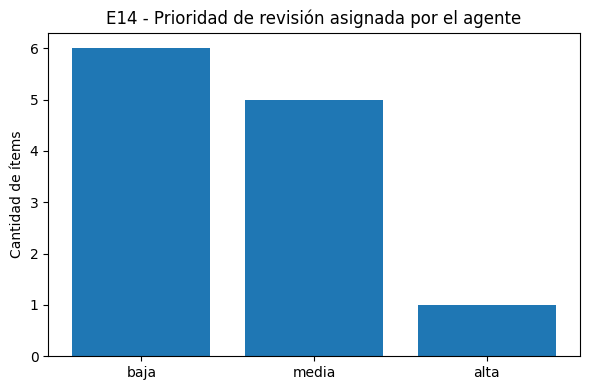

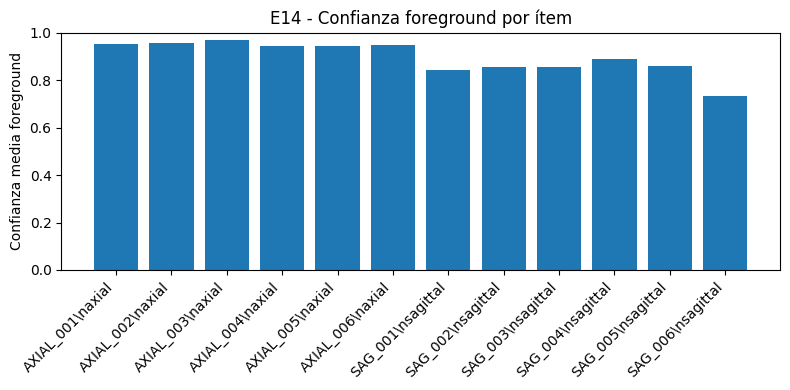

Figuras: /content/drive/MyDrive/PFI_MVP/figures/E14_agent_priority_summary.png /content/drive/MyDrive/PFI_MVP/figures/E14_agent_confidence_summary.png


In [6]:
priority_counts = agent_full_df["review_priority"].value_counts().reindex(["baja", "media", "alta"]).fillna(0)

plt.figure(figsize=(6, 4))
plt.bar(priority_counts.index, priority_counts.values)
plt.ylabel("Cantidad de ítems")
plt.title("E14 - Prioridad de revisión asignada por el agente")
plt.tight_layout()
priority_fig = FIGURES_ROOT / "E14_agent_priority_summary.png"
plt.savefig(priority_fig, dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 4))
plot_df = agent_full_df.copy()
plot_df["label"] = plot_df["agent_item_id"] + "\\n" + plot_df["plane"]
plt.bar(plot_df["label"], plot_df["mean_fg_confidence"])
plt.ylabel("Confianza media foreground")
plt.ylim(0, 1)
plt.title("E14 - Confianza foreground por ítem")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
conf_fig = FIGURES_ROOT / "E14_agent_confidence_summary.png"
plt.savefig(conf_fig, dpi=150, bbox_inches="tight")
plt.show()

print("Figuras:", priority_fig, conf_fig)


## 6. Reportes individuales por caso

Cada caso queda resumido en un Markdown simple que luego podría transformarse en una pantalla del MVP o en un reporte revisable por un profesional.


In [7]:
case_report_rows = []

for _, r in agent_full_df.iterrows():
    item_id = r["agent_item_id"]
    md_path = CASE_REPORTS_ROOT / f"E14_case_{item_id}.md"

    reasons = r["agent_reasons"]
    if isinstance(reasons, str):
        try:
            reasons = ast.literal_eval(reasons)
        except Exception:
            reasons = [reasons]

    reasons_text = "\\n".join([f"- {x}" for x in reasons]) if reasons else "- Sin observaciones automáticas."

    md_text = f"""# E14 - Reporte de agente IA: {item_id}

## Identificación

- Plano: {r['plane']}
- Caso: {r['case_ref']}
- Modelo seleccionado: {r['model_key']}
- Estado del agente: {r['agent_status']}
- Prioridad de revisión: {r['review_priority']}
- Revisión humana requerida: sí

## Calidad automática

- Foreground ratio: {r['foreground_ratio']:.4f}
- Componentes: {r['n_components']}
- Clases presentes: {r['present_classes']}
- Confianza media: {r['mean_confidence']:.4f}
- Confianza media foreground: {r['mean_fg_confidence']:.4f}

## Métricas disponibles

- Dice macro sin fondo: {r['dice_macro_no_bg']:.4f}
- IoU macro sin fondo: {r['iou_macro_no_bg']:.4f}
- Dice macro clases principales/útiles: {r['dice_macro_useful_classes']:.4f}
- IoU macro clases principales/útiles: {r['iou_macro_useful_classes']:.4f}

## Razones del agente

{reasons_text}

## Acción recomendada

{r['recommended_action']}

## Figura asociada

{r['figure_path']}

## Aclaración

Este reporte es una salida de apoyo. No constituye diagnóstico automático y debe ser revisado por un profesional.
"""

    md_path.write_text(md_text, encoding="utf-8")
    case_report_rows.append({
        "agent_item_id": item_id,
        "case_report_path": str(md_path),
    })

case_reports_df = pd.DataFrame(case_report_rows)
case_reports_path = E14_ROOT / "E14_agent_case_reports_index.csv"
case_reports_df.to_csv(case_reports_path, index=False)

display(case_reports_df)
print("Case reports index:", case_reports_path)


,agent_item_id,case_report_path
0,AXIAL_001,/content/drive/MyDrive/PFI_MVP/docs/E14_agent_case_reports/E14_case_AXIAL_001.md
1,AXIAL_002,/content/drive/MyDrive/PFI_MVP/docs/E14_agent_case_reports/E14_case_AXIAL_002.md
2,AXIAL_003,/content/drive/MyDrive/PFI_MVP/docs/E14_agent_case_reports/E14_case_AXIAL_003.md
3,AXIAL_004,/content/drive/MyDrive/PFI_MVP/docs/E14_agent_case_reports/E14_case_AXIAL_004.md
4,AXIAL_005,/content/drive/MyDrive/PFI_MVP/docs/E14_agent_case_reports/E14_case_AXIAL_005.md
5,AXIAL_006,/content/drive/MyDrive/PFI_MVP/docs/E14_agent_case_reports/E14_case_AXIAL_006.md
6,SAG_001,/content/drive/MyDrive/PFI_MVP/docs/E14_agent_case_reports/E14_case_SAG_001.md
7,SAG_002,/content/drive/MyDrive/PFI_MVP/docs/E14_agent_case_reports/E14_case_SAG_002.md
8,SAG_003,/content/drive/MyDrive/PFI_MVP/docs/E14_agent_case_reports/E14_case_SAG_003.md
9,SAG_004,/content/drive/MyDrive/PFI_MVP/docs/E14_agent_case_reports/E14_case_SAG_004.md


Case reports index: /content/drive/MyDrive/PFI_MVP/results/E14_ai_agent_orchestrator/E14_agent_case_reports_index.csv


## 7. Reporte global E14

In [8]:
def safe_float(x):
    try:
        if pd.isna(x):
            return None
        return float(x)
    except Exception:
        return None


priority_distribution = agent_full_df["review_priority"].value_counts().to_dict()
status_distribution = agent_full_df["agent_status"].value_counts().to_dict()
plane_distribution = agent_full_df["plane"].value_counts().to_dict()

report = {
    "notebook": "22_E14_ai_agent_orchestrator_colab",
    "goal": "AI agent/orchestrator prototype over E13 multiplanar inference outputs",
    "input_e13_report": str(E13_REPORT_PATH),
    "inputs": {
        "axial_quality_csv": str(AXIAL_QUALITY_PATH),
        "axial_metrics_csv": str(AXIAL_METRICS_PATH),
        "sagittal_quality_csv": str(SAG_QUALITY_PATH),
        "sagittal_metrics_csv": str(SAG_METRICS_PATH),
    },
    "outputs": {
        "worklist_csv": str(worklist_path),
        "decisions_csv": str(decisions_path),
        "metrics_summary_csv": str(metrics_summary_path),
        "decisions_with_metrics_csv": str(agent_full_path),
        "case_reports_index_csv": str(case_reports_path),
        "case_reports_dir": str(CASE_REPORTS_ROOT),
        "priority_figure": str(priority_fig),
        "confidence_figure": str(conf_fig),
    },
    "summary": {
        "total_items": int(len(agent_full_df)),
        "plane_distribution": plane_distribution,
        "priority_distribution": priority_distribution,
        "status_distribution": status_distribution,
        "mean_fg_confidence": safe_float(agent_full_df["mean_fg_confidence"].mean()),
        "mean_dice_macro_useful_classes": safe_float(agent_full_df["dice_macro_useful_classes"].mean()),
    },
    "agent_policy": {
        "human_review_required": True,
        "role": "decision_support_and_quality_orchestration",
        "does_not_replace_professional": True,
    },
    "decision": "agent_orchestrator_prototype_ready_for_mvp_or_backend_translation",
}

report_path = E14_ROOT / "E14_agent_report.json"
report_path.write_text(json.dumps(report, indent=2, ensure_ascii=False), encoding="utf-8")

md_text = f"""# E14 - Agente/orquestador IA

## Objetivo

E14 implementa un prototipo de agente/orquestador IA sobre las salidas del pipeline común E13. No entrena modelos nuevos; organiza resultados sagitales y axiales, interpreta quality flags, asigna prioridad de revisión y genera reportes automáticos.

## Entradas

- `{AXIAL_QUALITY_PATH}`
- `{AXIAL_METRICS_PATH}`
- `{SAG_QUALITY_PATH}`
- `{SAG_METRICS_PATH}`
- `{E13_REPORT_PATH}`

## Resultado

Se procesaron {len(agent_full_df)} ítems:

- Distribución por plano: {plane_distribution}
- Distribución por prioridad: {priority_distribution}
- Distribución por estado: {status_distribution}

## Política del agente

El agente no emite diagnóstico autónomo. Todas las salidas requieren revisión profesional. Su función es:

- seleccionar el modelo según el plano,
- consolidar métricas y quality flags,
- priorizar la revisión,
- generar reportes trazables.

## Salidas

- Worklist: `{worklist_path}`
- Decisiones: `{decisions_path}`
- Decisiones con métricas: `{agent_full_path}`
- Reporte JSON: `{report_path}`
- Reportes por caso: `{CASE_REPORTS_ROOT}`

## Decisión

El prototipo de agente/orquestador queda listo para traducirse a lógica de backend o para integrarse al MVP como capa de control y revisión humana.
"""

md_path = DOCS_ROOT / "E14_ai_agent_orchestrator_conclusion.md"
md_path.write_text(md_text, encoding="utf-8")

print("Reporte JSON:", report_path)
print("Reporte Markdown:", md_path)
print(json.dumps(report, indent=2, ensure_ascii=False))


Reporte JSON: /content/drive/MyDrive/PFI_MVP/results/E14_ai_agent_orchestrator/E14_agent_report.json
Reporte Markdown: /content/drive/MyDrive/PFI_MVP/docs/E14_ai_agent_orchestrator_conclusion.md
{
  "notebook": "22_E14_ai_agent_orchestrator_colab",
  "goal": "AI agent/orchestrator prototype over E13 multiplanar inference outputs",
  "input_e13_report": "/content/drive/MyDrive/PFI_MVP/results/E13_multiplanar_inference_pipeline/E13_multiplanar_pipeline_report.json",
  "inputs": {
    "axial_quality_csv": "/content/drive/MyDrive/PFI_MVP/results/E13_multiplanar_inference_pipeline/E13_axial_examples_quality.csv",
    "axial_metrics_csv": "/content/drive/MyDrive/PFI_MVP/results/E13_multiplanar_inference_pipeline/E13_axial_examples_metrics_by_class.csv",
    "sagittal_quality_csv": "/content/drive/MyDrive/PFI_MVP/results/E13_multiplanar_inference_pipeline/E13_sagittal_examples_quality.csv",
    "sagittal_metrics_csv": "/content/drive/MyDrive/PFI_MVP/results/E13_multiplanar_inference_pipeline/